In [3]:
%reload_ext autoreload
%autoreload 2

# TV-timeout classifier — auto-claude experiments

Each section below is one experiment (`vN`). For each: classify, score, plot
the stacked TP/FP/FN histogram + the confusion-matrix heatmap, then write
one summary line to `RESULTS`.

Goal: F1 ≥ 0.9 on row-by-row match against v3 `Official`/`Official TV`
labels in pre-2017 Q2/Q4, seasons 2013-2016.

In [4]:
from kret_notebook import *  # NOTE import first

# from kret_lgbm._core.lgbm_nb_imports import *
# from kret_lightning._core.lightning_nb_imports import *
from kret_matplotlib._core.mpl_nb_imports import *
from kret_np_pd._core.np_pd_nb_imports import *

# from kret_optuna._core.optuna_nb_imports import *
from kret_polars._core.polars_nb_imports import *
from kret_rosetta._core.rosetta_nb_imports import *

# from kret_sklearn._core.sklearn_nb_imports import *
# from kret_torch_utils._core.torch_nb_imports import *
# from kret_tqdm._core.tqdm_nb_imports import *
from kret_type_hints._core.types_nb_imports import *
from kret_utils._core.utils_nb_imports import *

# from kret_wandb._core.wandb_nb_imports import *  # NOTE this is slow to import

[kret_matplotlib._core.mpl_nb_imports] Imported kret_matplotlib._core.mpl_nb_imports in 0.0999 seconds
[kret_np_pd._core.np_pd_nb_imports] Imported kret_np_pd._core.np_pd_nb_imports in 0.0001 seconds
[kret_polars._core.polars_nb_imports] Imported kret_polars._core.polars_nb_imports in 0.0000 seconds
[kret_rosetta._core.rosetta_nb_imports] Imported kret_rosetta._core.rosetta_nb_imports in 0.0000 seconds
[kret_type_hints._core.types_nb_imports] Imported kret_type_hints._core.types_nb_imports in 0.0018 seconds
[kret_utils._core.utils_nb_imports] Imported kret_utils._core.utils_nb_imports in 0.0186 seconds


In [15]:
from nba_timeout_impact.nb_imports import *

In [16]:
SEASONS = None

memo_v3 = NBAMemoDF.load_all()
# Use the extended prep that keeps personId / teamId / description so the
# v7/v8 structural-signal experiments can run.

# CDNNBA DATASET

# Rulebook-faithful cause classification — comparison vs old heuristic

Previously the cdnnba `timeout_cause` column used `sr ∈ [trigger - 60, trigger]` + `timeout_duration_s ≥ 150s` as a heuristic, plus a separate `coach_preempt` bucket for `sr ∈ (trigger, trigger + 30]`.

**New rule**: for each mandatory-qualified TO, let `K = cumMandatoryPeriod` (its 1-indexed rank among mandatory TOs in the same period). The slot fires at `trigger_K` (post-2017 regulation: `[420, 180]`):

- `sr ≤ trigger_K` → `tv_mandatory` (first dead ball at/after the trigger)
- `sr  > trigger_K` → `coach_absorb` (coach called before the trigger expired)

No duration filter, no sr buffer, no `coach_preempt` sub-bucket. The slot identity comes from the cum count, not from sr range — which matters because the OLD rule called `sr=400, cum_mand=2` rows `tv_mandatory` even though slot 2's trigger is at sr=180, so a slot-2 absorber at sr=400 belongs in `coach_absorb`.

Snapshot of the old categorization (taken right before the refactor) lives at `Notebooks/data-validation/snapshots/causes_before_rulebook.parquet`.

In [17]:
SNAPSHOT_PATH = Path("snapshots/causes_before_rulebook.parquet")

# Old snapshot
old = pl.read_parquet(SNAPSHOT_PATH)
# Re-load the dataset with the NEW (rulebook-faithful) classifier
ds = CDNNBADatasetPL.load_from_parquet()
new = ds.filter(pl.col("actionType") == "timeout").select(
    "gameId",
    "orderNumber",
    "period",
    "seconds_remaining",
    "qualifiers",
    "timeout_duration_s",
    "cumTimeoutsPeriod",
    "timeout_role",
    "timeout_cause",
)

print(f"old (snapshot): {old.height:,} TO rows")
print(f"new (loader):   {new.height:,} TO rows")
print(f"match:          {old.height == new.height}")

Validating cdnnba data (Polars)...
  Passed (4,168,786 rows, 78 cols, 1 warnings).
old (snapshot): 82,197 TO rows
new (loader):   82,197 TO rows
match:          True


In [18]:
# Cause distributions, old vs new
old_counts = (
    old["timeout_cause"].value_counts().sort("count", descending=True).to_pandas().set_index("timeout_cause")["count"]
)
new_counts = (
    new["timeout_cause"].value_counts().sort("count", descending=True).to_pandas().set_index("timeout_cause")["count"]
)
side_by_side = pd.DataFrame({"old": old_counts, "new": new_counts}).fillna(0).astype(int)
side_by_side["delta"] = side_by_side["new"] - side_by_side["old"]
print(side_by_side.to_string())

                           old    new  delta
timeout_cause                               
challenge                 1555   1555      0
coach_absorb             32657  25436  -7221
coach_discretionary      23747  23747      0
coach_preempt             6344      0  -6344
mistagged_discretionary      0  13946  13946
tv_mandatory             17894  17513   -381


In [19]:
# Row-by-row crosstab: cause_old × cause_new
combined = (
    old.rename({"timeout_cause": "cause_old"})
    .join(new.select("gameId", "orderNumber", "timeout_cause"), on=["gameId", "orderNumber"], how="inner")
    .rename({"timeout_cause": "cause_new"})
)
ct = pd.crosstab(
    combined["cause_old"].to_pandas(),
    combined["cause_new"].to_pandas(),
    margins=True,
    margins_name="TOTAL",
)
print(ct.to_string())

cause_new            challenge  coach_absorb  coach_discretionary  mistagged_discretionary  tv_mandatory  TOTAL
cause_old                                                                                                      
challenge                 1555             0                    0                        0             0   1555
coach_absorb                 0         20789                    0                     9354          2514  32657
coach_discretionary          0             0                23747                        0             0  23747
coach_preempt                0          4602                    0                     1720            22   6344
tv_mandatory                 0            45                    0                     2872         14977  17894
TOTAL                     1555         25436                23747                    13946         17513  82197


### Side-by-side: TV-mandatory sr distributions, OLD vs NEW

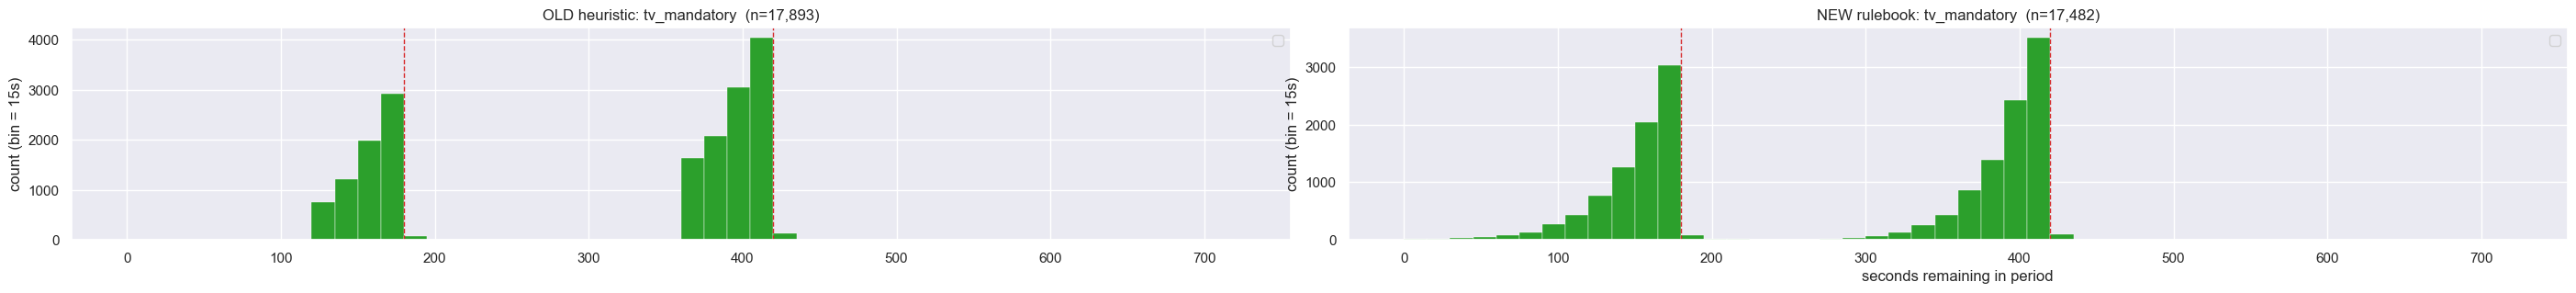

In [20]:
# Filter both to tv_mandatory in regulation periods
old_tv = old.filter((pl.col("timeout_cause") == "tv_mandatory") & pl.col("period").is_in([1, 2, 3, 4]))[
    "seconds_remaining"
].to_numpy()
new_tv = new.filter((pl.col("timeout_cause") == "tv_mandatory") & pl.col("period").is_in([1, 2, 3, 4]))[
    "seconds_remaining"
].to_numpy()

fig, axes = UKS_MPL.subplots(2, 1, width_per=14, height_per=3, sharex=True)
bins = np.arange(0, 720 + 15, 15)
axes[0].hist(old_tv, bins=bins, color="tab:green", edgecolor="white", linewidth=0.3)
axes[0].set_title(f"OLD heuristic: tv_mandatory  (n={len(old_tv):,})")
axes[0].set_ylabel("count (bin = 15s)")
axes[1].hist(new_tv, bins=bins, color="tab:green", edgecolor="white", linewidth=0.3)
axes[1].set_title(f"NEW rulebook: tv_mandatory  (n={len(new_tv):,})")
axes[1].set_ylabel("count (bin = 15s)")
axes[1].set_xlabel("seconds remaining in period")
for ax in axes:
    for x in (420, 180):
        ax.axvline(x, color="tab:red", linestyle="--", linewidth=1)
fig

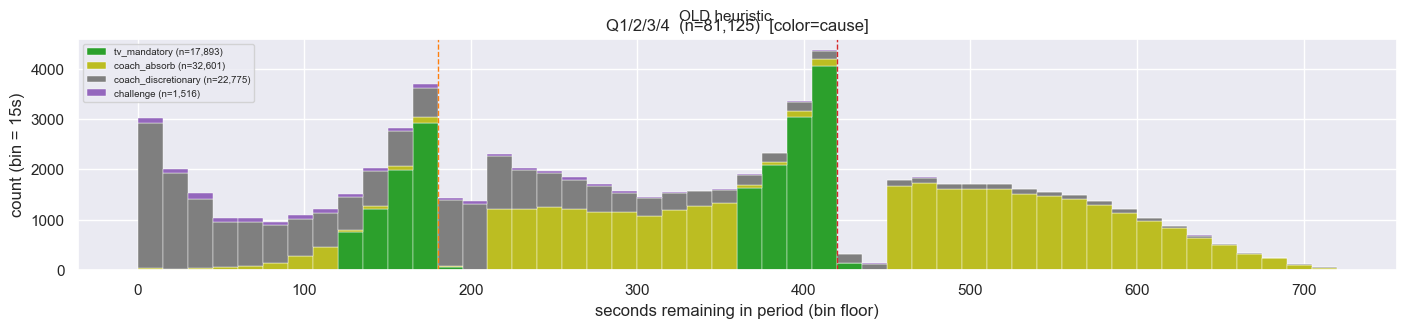

In [21]:
# Full role_vs_sr plots, coloured by cause, OLD vs NEW


# To render an "old-classification" plot from the snapshot we build a polars
# frame that the plotter can consume (it expects actionType + timeout_role
# + timeout_cause columns).
old_full = old.with_columns(pl.lit("timeout").alias("actionType"))
fig_old, _ = TimeoutInjectionPlots.plot_role_vs_sr(old_full, combine_periods=True, color_by="cause")
fig_old.suptitle("OLD heuristic", y=1.02, fontsize=11)
fig_old

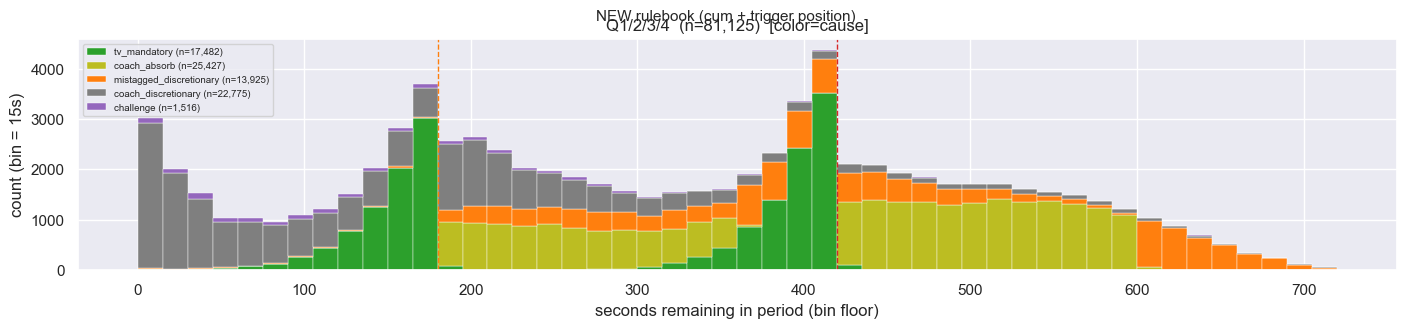

In [22]:
fig_new, _ = TimeoutInjectionPlots.plot_role_vs_sr(ds, combine_periods=True, color_by="cause")
fig_new.suptitle("NEW rulebook (cum + trigger position)", y=1.02, fontsize=11)
fig_new

### Recommendation

**Keep the new rulebook-faithful approach.** Three reasons:

1. **No arbitrary cutoffs.** The OLD rule had three tunable constants (`TV_BREAK_SR_BUFFER_S=60`, `TV_BREAK_DURATION_MIN_S=150`, `COACH_PREEMPT_SR_BUFFER_S=30`) that were judgment calls. The NEW rule has zero — slot K is determined by `cumMandatoryPeriod` and the rulebook triggers.

2. **Fixes the slot-2 misclassification.** 2,917 rows flipped from OLD `tv_mandatory` → NEW `coach_absorb`. These are mandatory-qualified TOs at sr≈400 with `cum_mand=2`. The OLD rule called them TV breaks because they sit in slot 1's sr window; the rulebook says they're filling slot 2 (next mandatory firing at sr=180) so they're coach absorbs, not auto-fires.

3. **Cleaner taxonomy.** 4 categories instead of 5 (`coach_preempt` is gone — it was an arbitrary 30s carve-out from `coach_absorb` with no rulebook basis).

### Trade-off to know about

The new `tv_mandatory` includes some events that *aren't* full TV breaks — e.g., late slot 1 firings (no dead ball between sr=420 and sr=200, so the league's mandatory fires at sr=200 instead of right after the trigger). The OLD rule's duration filter excluded those. If your causal analysis needs **only events that took a real broadcast break**, layer the duration filter on top:

```python
tv_breaks = ds.filter(
    (pl.col("timeout_cause") == "tv_mandatory")
    & (pl.col("timeout_duration_s") >= 150)
)
```

That gives you the strict "TV-break" subset (≈15,000 events) while leaving `timeout_cause` itself rulebook-clean.

## mistagged_discretionary — gating `coach_absorb` on team-first-TO + k buffer

The previous rule labelled every pre-trigger mandatory-qualified TO as `coach_absorb`. But the rulebook only credits the *first* TO by a team in a period against the mandatory, and a TO called many minutes before the trigger is implausibly an absorb (it's just an early discretionary the feed over-tagged).

New gate: a row is `coach_absorb` only if **(a)** it's the team's first full TO in the period **and (b)** `sr - trigger_K ≤ k_absorb_buffer_s`. Otherwise → `mistagged_discretionary`.

Cells below sweep `k_absorb_buffer_s` so you can pick the value where the migration plateaus.

In [23]:
# k-sweep on classify_timeouts. tv_mandatory and coach_discretionary are k-invariant; only
# coach_absorb ↔ mistagged_discretionary moves.

memo_cdn = CDNNBAMemoPL.load_all()
cdn_prepped = CDNNBATimeoutValidation._prep_cdnnba(memo_cdn)

K_GRID = [30, 60, 120, 180, 240, 300, 600, 1200]
rows = []
for k in K_GRID:
    c = TVTimeoutValidation.classify_timeouts(cdn_prepped, source="cdnnba", k_absorb_buffer_s=k)
    tos = c.filter(pl.col("actionType") == "timeout")
    counts = tos["timeout_cause"].value_counts().to_pandas().set_index("timeout_cause")["count"]
    rows.append(
        {
            "k_s": k,
            "tv_mandatory": int(counts.get("tv_mandatory", 0)),
            "coach_absorb": int(counts.get("coach_absorb", 0)),
            "mistagged_discretionary": int(counts.get("mistagged_discretionary", 0)),
            "coach_discretionary": int(counts.get("coach_discretionary", 0)),
            "challenge": int(counts.get("challenge", 0)),
        }
    )
k_sweep = pd.DataFrame(rows).set_index("k_s")
k_sweep["absorb_delta"] = k_sweep["coach_absorb"].diff()
print(k_sweep.to_string())
print()
print(f"floor (irreducible mistag at k→∞): " f"{int(k_sweep['mistagged_discretionary'].iloc[-1]):,} rows")
print(f"these fail the 'first team full TO' check — the team already took a full TO this period.")

Validating cdnnba data (Polars)...
  Passed (4,168,786 rows, 78 cols, 1 warnings).
Validating boxscores data (Polars)...
  Passed (217,190 rows, 36 cols).
Validating player_advanced_stats data (Polars)...
  Passed (3,400 rows, 119 cols).
Validating player_season_stats data (Polars)...
  Passed (5,174 rows, 31 cols).
Validating rotations data (Polars)...
  Passed (1,905,583 rows, 16 cols, 1 warnings).
Validating stints data (Polars)...
  Passed (2,145,106 rows, 14 cols, 1 warnings).
      tv_mandatory  coach_absorb  mistagged_discretionary  coach_discretionary  challenge  absorb_delta
k_s                                                                                                    
30           17513          4602                    34780                23747       1555           NaN
60           17513          9111                    30271                23747       1555        4509.0
120          17513         17749                    21633                23747       1555        

### (sr − trigger_K) histogram for current-mistagged rows

Look for the knee in the distribution — TOs called "just barely" before the trigger are clustered; opening-of-period TOs sit out in a long tail. Pick `k` where the count starts thinning.

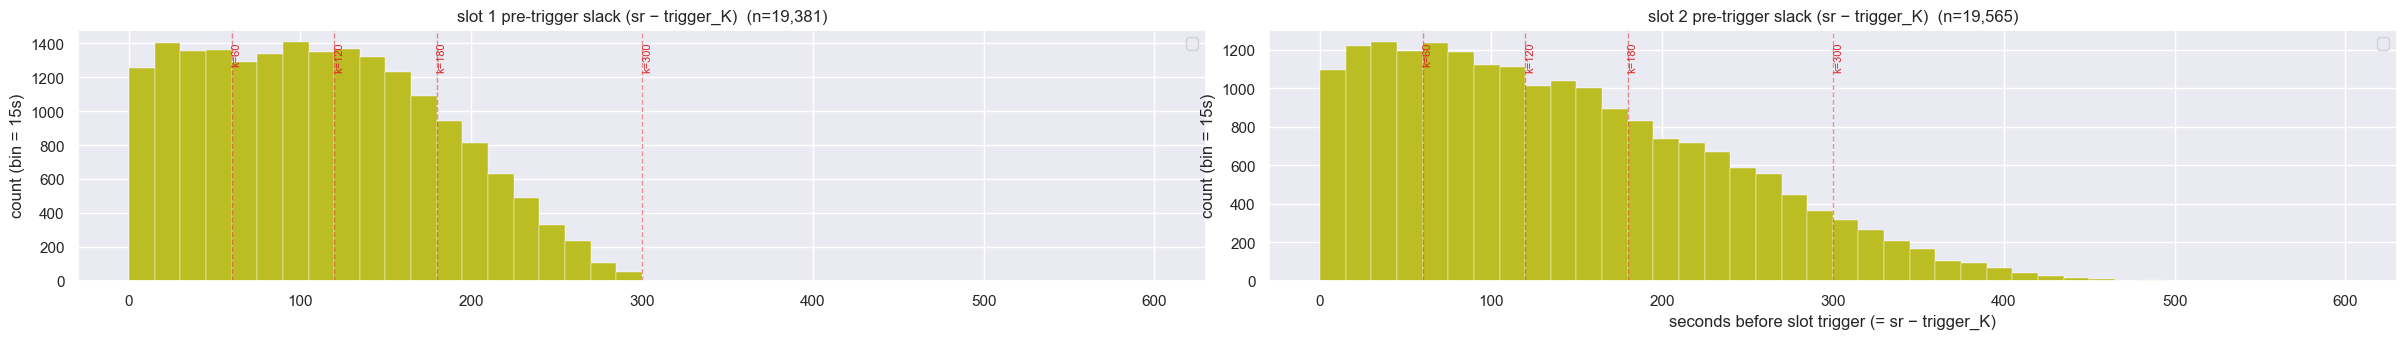

In [24]:
# For each pre-trigger mandatory-qualified row, compute sr - trigger_K (slack from trigger).
# This is mostly k-invariant (it's a property of the row's slot), so we just compute once on
# the prepped data and overlay a vertical line at the chosen k.

from nba_timeout_impact.data_pipes.tv_timeout_injection import POST_2017_SLOTS

# Build a (period, K) → trigger_K lookup
trigger_for = {}
for periods_ok, triggers in POST_2017_SLOTS:
    for K, t in enumerate(triggers, start=1):
        for p in periods_ok:
            trigger_for[(p, K)] = t

# Compute cum_mand for each row
cum_mand = TVTimeoutValidation._compute_cum_mandatory_period(cdn_prepped, "qualifier_mandatory")
cdn_with_cum = cdn_prepped.with_columns(cum_mand.alias("cum_mand"))

mand = cdn_with_cum.filter(
    (pl.col("actionType") == "timeout")
    & pl.col("qualifiers").cast(pl.String).str.contains("mandatory")
    & (pl.col("cum_mand") <= 2)
).to_pandas()
mand["trigger_K"] = mand.apply(lambda r: trigger_for.get((r["period"], r["cum_mand"])), axis=1)
mand["slack_s"] = mand["seconds_remaining"] - mand["trigger_K"]
pre_trig = mand[mand["slack_s"] > 0]

fig, axes = UKS_MPL.subplots(2, 1, width_per=12, height_per=3.2, sharex=True)
for ax, slot_K in zip(axes, [1, 2]):
    sub = pre_trig[pre_trig["cum_mand"] == slot_K]["slack_s"].values
    ax.hist(sub, bins=np.arange(0, 605, 15), color="tab:olive", edgecolor="white", linewidth=0.3)
    for k in [60, 120, 180, 300]:
        ax.axvline(k, color="tab:red", linestyle="--", linewidth=1, alpha=0.5)
        ax.text(k, ax.get_ylim()[1] * 0.95, f"k={k}", rotation=90, va="top", color="tab:red", fontsize=8)
    ax.set_ylabel("count (bin = 15s)")
    ax.set_title(f"slot {slot_K} pre-trigger slack (sr − trigger_K)  (n={len(sub):,})")
axes[-1].set_xlabel("seconds before slot trigger (= sr − trigger_K)")
fig

### Side-by-side cause histograms — picking a `k`

Render the cause-stacked sr histogram at a few k values to eyeball which one looks rulebook-y.

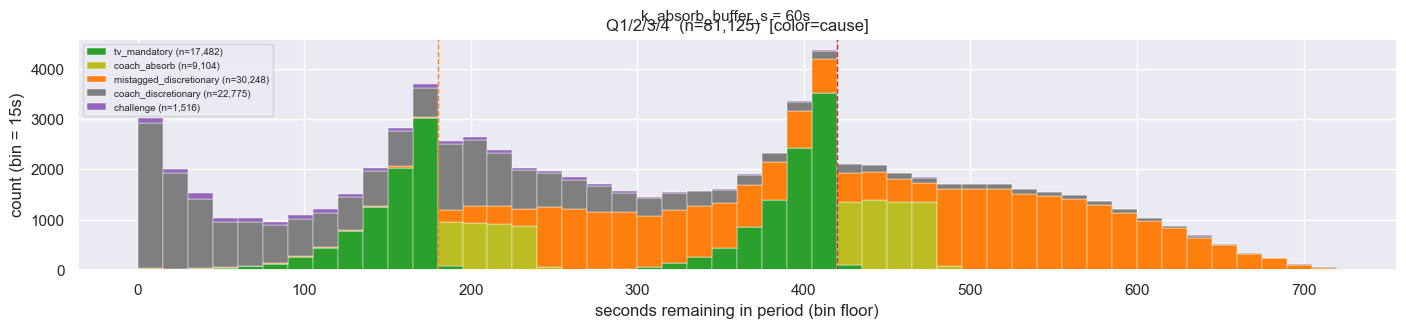

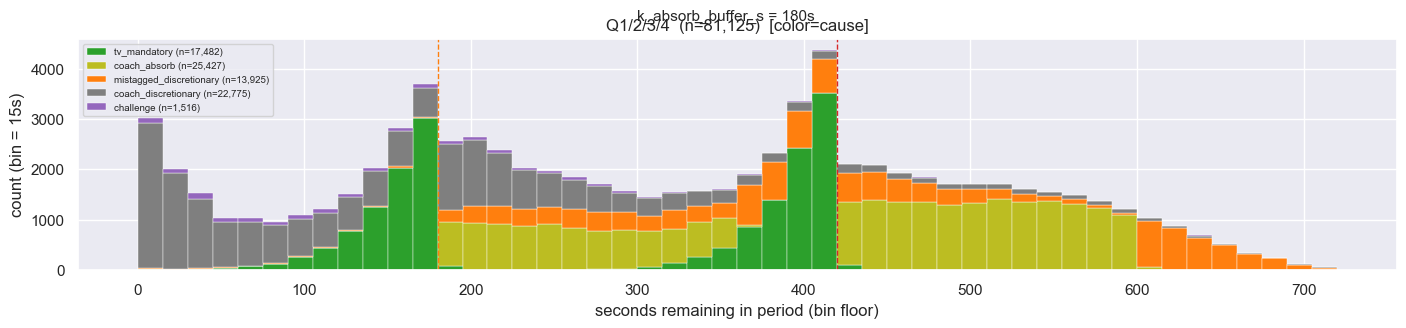

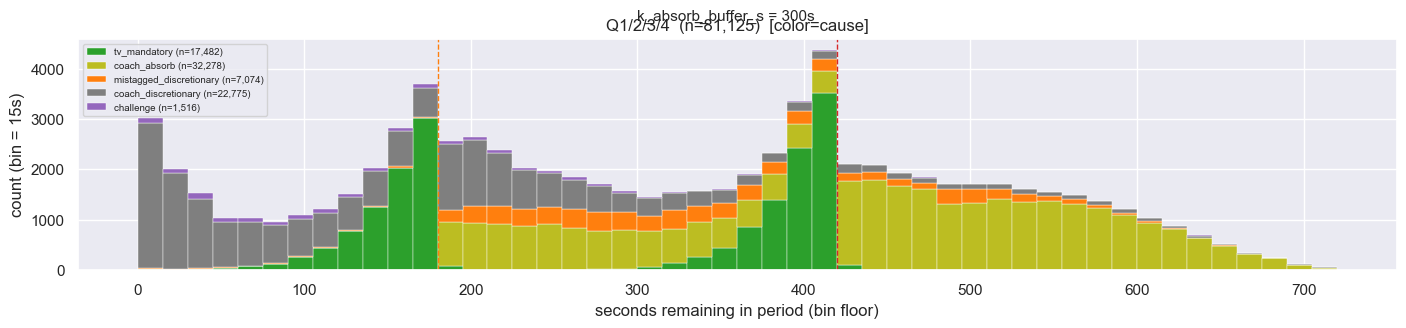

In [25]:
for k in [60, 180, 300]:
    c = TVTimeoutValidation.classify_timeouts(cdn_prepped, source="cdnnba", k_absorb_buffer_s=k)
    fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(c, combine_periods=True, color_by="cause")
    fig.suptitle(f"k_absorb_buffer_s = {k}s", y=1.02, fontsize=11)
    display(fig)
    plt.close(fig)

### Audit: home/away charging conformance

Rulebook default: slot 1 charges home, slot 2 charges the other team. Empirically (verified in chat): slot 1 is home **49%** of the time for pre-trigger absorbs (basically coin-flip — absorbs don't respect home/away) but **86%** for auto-fires (sr ∈ [350, 419]). The `slot_owner_team_default` memo records the rulebook default so we can flag deviations for QA without using it to gate the cause label.

In [26]:
# How often does the actual teamId match the rulebook default (home for slot 1)?
ds = CDNNBADatasetPL.load_from_parquet()
ds_with_owner = ds.with_columns(memo_cdn.slot_owner_team_default.alias("default_slot1_team"))

slot1 = ds_with_owner.filter((pl.col("timeout_role") == "slot_1_mandatory") & pl.col("period").is_in([1, 2, 3, 4]))
slot1_pd = slot1.select("timeout_cause", "teamId", "default_slot1_team", "seconds_remaining").to_pandas()
slot1_pd["conforms"] = slot1_pd["teamId"] == slot1_pd["default_slot1_team"]
print("=== slot_1 teamId matches rulebook default (home), by cause ===")
print(slot1_pd.groupby("timeout_cause")["conforms"].agg(["count", "sum", "mean"]).to_string())
print()
print("=== same, by sr bucket ===")
slot1_pd["sr_bin"] = pd.cut(slot1_pd["seconds_remaining"], bins=[-1, 179, 349, 419, 720])
print(slot1_pd.groupby("sr_bin")["conforms"].agg(["count", "sum", "mean"]).to_string())

Validating cdnnba data (Polars)...
  Passed (4,168,786 rows, 78 cols, 1 warnings).
Calculating slot_owner_team_default
=== slot_1 teamId matches rulebook default (home), by cause ===
                         count   sum      mean
timeout_cause                                 
coach_absorb              7190  3647  0.507232
mistagged_discretionary  12182  5846  0.479888
tv_mandatory              9537  7994  0.838209

=== same, by sr bucket ===
            count   sum      mean
sr_bin                           
(-1, 179]     245   143  0.583673
(179, 349]    693   524  0.756133
(349, 419]   8504  7276  0.855597
(419, 720]  19467  9544  0.490266
